# Research Assistant

## Review

We've covered a few major LangGraph themes:

* Memory
* Human-in-the-loop
* Controllability

Now, we'll bring these ideas together to tackle one of AI's most popular applications: research automation. 

Research is often laborious work offloaded to analysts. AI has considerable potential to assist with this.

However, research demands customization: raw LLM outputs are often poorly suited for real-world decision-making workflows. 

Customized, AI-based [research and report generation](https://jxnl.co/writing/2024/06/05/predictions-for-the-future-of-rag/#reports-over-rag) workflows are a promising way to address this.

## Goal

Our goal is to build a lightweight, multi-agent system around chat models that customizes the research process.

`Source Selection` 
* Users can choose any set of input sources for their research.
  
`Planning` 
* Users provide a topic, and the system generates a team of AI analysts, each focusing on one sub-topic.
* `Human-in-the-loop` will be used to refine these sub-topics before research begins.
  
`LLM Utilization`
* Each analyst will conduct in-depth interviews with an expert AI using the selected sources.
* The interview will be a multi-turn conversation to extract detailed insights as shown in the [STORM](https://arxiv.org/abs/2402.14207) paper.
* These interviews will be captured in a using `sub-graphs` with their internal state. 
   
`Research Process`
* Experts will gather information to answer analyst questions in `parallel`.
* And all interviews will be conducted simultaneously through `map-reduce`.

`Output Format` 
* The gathered insights from each interview will be synthesized into a final report.
* We'll use customizable prompts for the report, allowing for a flexible output format. 

![Screenshot 2024-08-26 at 7.26.33 PM.png](https://cdn.prod.website-files.com/65b8cd72835ceeacd4449a53/66dbb164d61c93d48e604091_research-assistant1.png)

In [1]:
from langchain.chat_models import init_chat_model

llm = init_chat_model(
    model="models/gemini-3.5-flash-lite", 
    model_provider="google_genai",
    max_retries = 5
)

## Generate Analysts: Human-In-The-Loop

Create analysts and review them using human-in-the-loop.

In [2]:
from typing import List
from typing_extensions import TypedDict
from pydantic import BaseModel, Field

class Analyst(BaseModel):
    affiliation: str = Field(
        description="Primary affiliation of the analyst.",
    )
    name: str = Field(
        description="Name of the analyst."
    )
    role: str = Field(
        description="Role of the analyst in the context of the topic.",
    )
    description: str = Field(
        description="Description of the analyst focus, concerns, and motives.",
    )
    @property
    def persona(self) -> str:
        return f"Name: {self.name}\nRole: {self.role}\nAffiliation: {self.affiliation}\nDescription: {self.description}\n"

class Perspectives(BaseModel):
    analysts: List[Analyst] = Field(
        description="Comprehensive list of analysts with their roles and affiliations.",
    )

class GenerateAnalystsState(TypedDict):
    topic: str # Research topic
    max_analysts: int # Number of analysts
    human_analyst_feedback: str # Human feedback
    analysts: List[Analyst] # Analyst asking questions

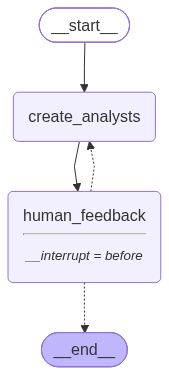

In [ ]:
from IPython.display import Image, display
from langgraph.graph import START, END, StateGraph
from langgraph.checkpoint.memory import MemorySaver
from langchain_core.messages import AIMessage, HumanMessage, SystemMessage

analyst_instructions="""You are tasked with creating a set of AI analyst personas. Follow these instructions carefully:

1. First, review the research topic:
{topic}
        
2. Examine any editorial feedback that has been optionally provided to guide creation of the analysts: 
        
{human_analyst_feedback}
    
3. Determine the most interesting themes based upon documents and / or feedback above.
                    
4. Pick the top {max_analysts} themes.

5. Assign one analyst to each theme."""

def create_analysts(state: GenerateAnalystsState):
    
    """ Create analysts """
    
    topic=state['topic']
    max_analysts=state['max_analysts']   
    human_analyst_feedback=state.get('human_analyst_feedback', '')
        
    # Enforce structured output
    structured_llm = llm.with_structured_output(Perspectives)

    # System message
    system_message = analyst_instructions.format(topic=topic,
                                                            human_analyst_feedback=human_analyst_feedback, 
                                                            max_analysts=max_analysts)

    # Generate question 
    analysts = structured_llm.invoke([SystemMessage(content=system_message)]+[HumanMessage(content="Generate the set of analysts.")])
    
    # Write the list of analysis to state
    return {"analysts": analysts.analysts}

def human_feedback(state: GenerateAnalystsState):
    """ No-op node that should be interrupted on """
    pass

def should_continue(state: GenerateAnalystsState):
    """ Return the next node to execute """

    # Check if human feedback
    human_analyst_feedback=state.get('human_analyst_feedback', None)
    if human_analyst_feedback:
        return "create_analysts"
    
    # Otherwise end
    return END

# Add nodes and edges 
builder = StateGraph(GenerateAnalystsState)
builder.add_node("create_analysts", create_analysts)
builder.add_node("human_feedback", human_feedback)
builder.add_edge(START, "create_analysts")
builder.add_edge("create_analysts", "human_feedback")
builder.add_conditional_edges("human_feedback", should_continue, ["create_analysts", END])

# Compile
memory = MemorySaver()
graph = builder.compile(interrupt_before=['human_feedback'], checkpointer=memory)

# View
display(Image(graph.get_graph(xray=1).draw_mermaid_png()))

In [4]:
# Input
max_analysts = 1 
topic = "The benefits of adopting LangGraph as an agent framework"
thread = {"configurable": {"thread_id": "1"}}

# Run the graph until the first interruption
for event in graph.stream({"topic":topic,"max_analysts":max_analysts,}, thread, stream_mode="values"):
    # Review
    analysts = event.get('analysts', '')
    if analysts:
        for analyst in analysts:
            print(f"Name: {analyst.name}")
            print(f"Affiliation: {analyst.affiliation}")
            print(f"Role: {analyst.role}")
            print(f"Description: {analyst.description}")
            print("-" * 50)  

Direct use of automatic function calling (AFC) in Models.generate_content is not recommended. Instead, we recommend to use AFC in Chat.send_message. Similarly, direct use of AFC in Models.generate_content_stream is not recommended. Instead, we recommend to use AFC in Chat.send_message_stream.


Name: Dr. Elena Vance
Affiliation: Enterprise AI Architecture Group
Role: Lead Systems Architect
Description: Focused on the structural reliability, state management, and cyclical workflow advantages of adopting LangGraph for complex, production-grade enterprise agents.
--------------------------------------------------


In [5]:
# Get state and look at next node
state = graph.get_state(thread)
state.next

Deserializing unregistered type __main__.Analyst from checkpoint. This will be blocked in a future version. Set LANGGRAPH_STRICT_MSGPACK=true to block now, or add to allowed_msgpack_modules to allow explicitly: [('__main__', 'Analyst')]


('human_feedback',)

In [6]:
# We now update the state as if we are the human_feedback node
graph.update_state(thread, {"human_analyst_feedback": 
                            "Add in someone from a startup to add an entrepreneur perspective"}, as_node="human_feedback")

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f1b058b-17e2-6a47-8002-92b13bc2978a'}}

In [7]:
# Continue the graph execution
for event in graph.stream(None, thread, stream_mode="values"):
    # Review
    analysts = event.get('analysts', '')
    if analysts:
        for analyst in analysts:
            print(f"Name: {analyst.name}")
            print(f"Affiliation: {analyst.affiliation}")
            print(f"Role: {analyst.role}")
            print(f"Description: {analyst.description}")
            print("-" * 50) 

Name: Dr. Elena Vance
Affiliation: Enterprise AI Architecture Group
Role: Lead Systems Architect
Description: Focused on the structural reliability, state management, and cyclical workflow advantages of adopting LangGraph for complex, production-grade enterprise agents.
--------------------------------------------------
Name: Alex Mercer
Affiliation: AgileAI Startup
Role: Startup Founder and CEO
Description: Focused on the entrepreneurial perspective, Alex evaluates LangGraph through the lens of speed-to-market, resource efficiency, and how quickly an early-stage startup can build, iterate, and scale reliable AI agents to secure a competitive advantage.
--------------------------------------------------


In [8]:
# If we are satisfied, then we simply supply no feedback
further_feedack = None
graph.update_state(thread, {"human_analyst_feedback": 
                            further_feedack}, as_node="human_feedback")

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f1b058b-237c-6ca4-8004-41aaefe1e8fc'}}

In [9]:
# Continue the graph execution to end
for event in graph.stream(None, thread, stream_mode="updates"):
    print("--Node--")
    node_name = next(iter(event.keys()))
    print(node_name)

In [10]:
final_state = graph.get_state(thread)
analysts = final_state.values.get('analysts')

In [11]:
final_state.next

()

In [12]:
for analyst in analysts:
    print(f"Name: {analyst.name}")
    print(f"Affiliation: {analyst.affiliation}")
    print(f"Role: {analyst.role}")
    print(f"Description: {analyst.description}")
    print("-" * 50) 

Name: Alex Mercer
Affiliation: AgileAI Startup
Role: Startup Founder and CEO
Description: Focused on the entrepreneurial perspective, Alex evaluates LangGraph through the lens of speed-to-market, resource efficiency, and how quickly an early-stage startup can build, iterate, and scale reliable AI agents to secure a competitive advantage.
--------------------------------------------------


## Conduct Interview

### Generate Question

The analyst will ask questions to the expert.

In [13]:
import operator
from typing import  Annotated
from langgraph.graph import MessagesState

class InterviewState(MessagesState):
    max_num_turns: int # Number turns of conversation
    context: Annotated[list, operator.add] # Source docs
    analyst: Analyst # Analyst asking questions
    interview: str # Interview transcript
    sections: list # Final key we duplicate in outer state for Send() API

class SearchQuery(BaseModel):
    search_query: str = Field(None, description="Search query for retrieval.")

In [14]:
import time

question_instructions = """You are an analyst tasked with interviewing an expert to learn about a specific topic. 

Your goal is boil down to interesting and specific insights related to your topic.

1. Interesting: Insights that people will find surprising or non-obvious.
        
2. Specific: Insights that avoid generalities and include specific examples from the expert.

Here is your topic of focus and set of goals: {goals}
        
Begin by introducing yourself using a name that fits your persona, and then ask your question.

Continue to ask questions to drill down and refine your understanding of the topic.
        
When you are satisfied with your understanding, complete the interview with: "Thank you so much for your help!"

Remember to stay in character throughout your response, reflecting the persona and goals provided to you."""

def generate_question(state: InterviewState):
    """ Node to generate an analyst question """
    analyst = state["analyst"]
    system_message = question_instructions.format(goals=analyst.persona)
    
    # Format dialogue as text inside a HumanMessage
    history_str = get_buffer_string(state["messages"])
    prompt = HumanMessage(content=f"Here is the interview so far:\n\n{history_str}\n\nAsk your next question to the expert:")

    time.sleep(4)
    
    question = llm.invoke([SystemMessage(content=system_message), prompt])
    return {"messages": [AIMessage(content=question.content, name="analyst")]}

### Generate Answer: Parallelization

The expert will gather information from multiple sources in parallel to answer questions.

For example, we can use:

* Specific web sites e.g., via [`WebBaseLoader`](https://docs.langchain.com/oss/python/integrations/document_loaders/web_base)
* Indexed documents e.g., via [RAG](https://docs.langchain.com/oss/python/langchain/retrieval)
* Web search
* Wikipedia search

You can try different web search tools, like [Tavily](https://tavily.com/).

In [15]:
# Web search tool
from langchain_tavily import TavilySearch  # updated 1.0

tavily_search = TavilySearch(max_results=3)

In [16]:
# Wikipedia search tool
from langchain_community.document_loaders import WikipediaLoader

C:\Users\reich\AppData\Local\Temp\ipykernel_12460\2780612488.py:2: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import WikipediaLoader
c:\Users\reich\Downloads\LangChain-Academy\2 - Introduction to LangGraph\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[transformers] PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


Now, we create nodes to search the web and wikipedia.

We'll also create a node to answer analyst questions.

Finally, we'll create nodes to save the full interview and to write a summary ("section") of the interview.

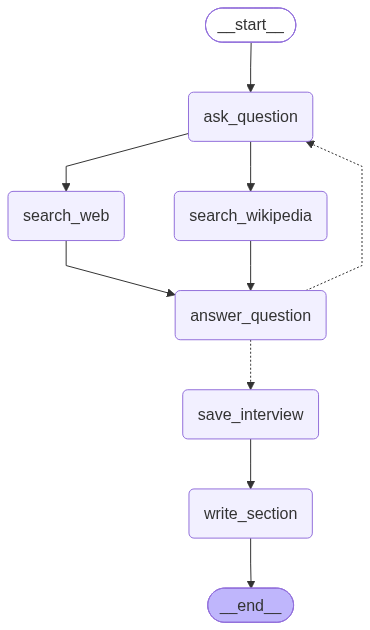

In [ ]:
from langchain_core.messages import get_buffer_string

# Search query writing
search_instructions = SystemMessage(content=f"""You will be given a conversation between an analyst and an expert. 

Your goal is to generate a well-structured query for use in retrieval and / or web-search related to the conversation.
        
First, analyze the full conversation.

Pay particular attention to the final question posed by the analyst.

Convert this final question into a well-structured web search query""")

from langchain_core.messages import get_buffer_string, HumanMessage

def search_web(state: InterviewState):
    """ Retrieve docs directly from web search """
    query = state['messages'][-1].content
    try:
        data = tavily_search.invoke({"query": query})
        search_docs = data.get("results", data)
        formatted = "\n\n---\n\n".join([f'<Document href="{d.get("url", "")}"/>\n{d.get("content", "")[:300]}...\n</Document>' for d in search_docs[:2]])
        return {"context": [formatted]}
    except Exception as e:
        return {"context": [f"Web search error: {e}"]}


def search_wikipedia(state: InterviewState):
    """ Retrieve docs directly from wikipedia """
    query = state['messages'][-1].content
    try:
        search_docs = WikipediaLoader(query=query[:50], load_max_docs=1).load()
        formatted = "\n\n---\n\n".join([f'<Document source="{d.metadata.get("source", "")}"/>\n{d.page_content[:300]}...\n</Document>' for d in search_docs])
        return {"context": [formatted]}
    except Exception as e:
        return {"context": [f"Wikipedia error: {e}"]} 
    
answer_instructions = """You are an expert being interviewed by an analyst.

Here is analyst area of focus: {goals}. 
        
You goal is to answer a question posed by the interviewer.

To answer question, use this context:
        
{context}

When answering questions, follow these guidelines:
        
1. Use only the information provided in the context. 
        
2. Do not introduce external information or make assumptions beyond what is explicitly stated in the context.

3. The context contain sources at the topic of each individual document.

4. Include these sources your answer next to any relevant statements. For example, for source # 1 use [1]. 

5. List your sources in order at the bottom of your answer. [1] Source 1, [2] Source 2, etc
        
6. If the source is: <Document source="assistant/docs/llama3_1.pdf" page="7"/>' then just list: 
        
[1] assistant/docs/llama3_1.pdf, page 7 
        
And skip the addition of the brackets as well as the Document source preamble in your citation."""
                            
def generate_answer(state: InterviewState):
    """ Node to answer the analyst's question """
    analyst = state["analyst"]
    context_str = "\n\n".join(state.get("context", []))
    
    system_message = answer_instructions.format(goals=analyst.persona, context=context_str)
    history_str = get_buffer_string(state["messages"])
    user_prompt = HumanMessage(content=f"Here is the interview dialogue and latest question:\n\n{history_str}\n\nAnswer the question using strictly the gathered context:")

    time.sleep(4)
    
    answer = llm.invoke([SystemMessage(content=system_message), user_prompt])
    return {"messages": [AIMessage(content=answer.content, name="expert")]}

def save_interview(state: InterviewState):
    """ Save interview transcript """
    interview = get_buffer_string(state["messages"])
    return {"interview": interview}

def route_messages(state: InterviewState, name: str = "expert"):
    """ 1 solid turn to keep calls ultra lean """
    return "save_interview"
    
section_writer_instructions = """You are an expert technical writer. 
            
Your task is to create a short, easily digestible section of a report based on a set of source documents.

1. Analyze the content of the source documents: 
- The name of each source document is at the start of the document, with the <Document tag.
        
2. Create a report structure using markdown formatting:
- Use ## for the section title
- Use ### for sub-section headers
        
3. Write the report following this structure:
a. Title (## header)
b. Summary (### header)
c. Sources (### header)

4. Make your title engaging based upon the focus area of the analyst: 
{focus}

5. For the summary section:
- Set up summary with general background / context related to the focus area of the analyst
- Emphasize what is novel, interesting, or surprising about insights gathered from the interview
- Create a numbered list of source documents, as you use them
- Do not mention the names of interviewers or experts
- Aim for approximately 400 words maximum
- Use numbered sources in your report (e.g., [1], [2]) based on information from source documents
        
6. In the Sources section:
- Include all sources used in your report
- Provide full links to relevant websites or specific document paths
- Separate each source by a newline. Use two spaces at the end of each line to create a newline in Markdown.
- It will look like:

### Sources
[1] Link or Document name
[2] Link or Document name

7. Be sure to combine sources. For example this is not correct:

[3] https://ai.meta.com/blog/meta-llama-3-1/
[4] https://ai.meta.com/blog/meta-llama-3-1/

There should be no redundant sources. It should simply be:

[3] https://ai.meta.com/blog/meta-llama-3-1/
        
8. Final review:
- Ensure the report follows the required structure
- Include no preamble before the title of the report
- Check that all guidelines have been followed"""

def write_section(state: InterviewState):
    """ Write report memo from interview """
    context_str = "\n\n".join(state.get("context", []))
    analyst = state["analyst"]
   
    system_message = section_writer_instructions.format(focus=analyst.description)
    user_prompt = HumanMessage(content=f"Use this source context to write your report section:\n\n{context_str}")
    
    section = llm.invoke([SystemMessage(content=system_message), user_prompt])
    return {"sections": [section.content]}

# Add nodes and edges 
interview_builder = StateGraph(InterviewState)
interview_builder.add_node("ask_question", generate_question)
interview_builder.add_node("search_web", search_web)
interview_builder.add_node("search_wikipedia", search_wikipedia)
interview_builder.add_node("answer_question", generate_answer)
interview_builder.add_node("save_interview", save_interview)
interview_builder.add_node("write_section", write_section)

# Flow
interview_builder.add_edge(START, "ask_question")
interview_builder.add_edge("ask_question", "search_web")
interview_builder.add_edge("ask_question", "search_wikipedia")
interview_builder.add_edge("search_web", "answer_question")
interview_builder.add_edge("search_wikipedia", "answer_question")
interview_builder.add_conditional_edges("answer_question", route_messages,['ask_question','save_interview'])
interview_builder.add_edge("save_interview", "write_section")
interview_builder.add_edge("write_section", END)

# Interview 
memory = MemorySaver()
interview_graph = interview_builder.compile(checkpointer=memory).with_config(run_name="Conduct Interviews")

# View
display(Image(interview_graph.get_graph().draw_mermaid_png()))

In [18]:
# Pick one analyst
analysts[0]

Analyst(affiliation='AgileAI Startup', name='Alex Mercer', role='Startup Founder and CEO', description='Focused on the entrepreneurial perspective, Alex evaluates LangGraph through the lens of speed-to-market, resource efficiency, and how quickly an early-stage startup can build, iterate, and scale reliable AI agents to secure a competitive advantage.')

Here, we run the interview passing an index of the llama3.1 paper, which is related to our topic.

In [19]:
from IPython.display import Markdown
messages = [HumanMessage(f"So you said you were writing an article on {topic}?")]
thread = {"configurable": {"thread_id": "1"}}
interview = interview_graph.invoke({"analyst": analysts[0], "messages": messages, "max_num_turns": 2}, thread)
sec = interview['sections'][0]
Markdown(sec[0]['text'] if isinstance(sec, list) else sec)

c:\Users\reich\Downloads\LangChain-Academy\2 - Introduction to LangGraph\.venv\Lib\site-packages\wikipedia\wikipedia.py:389: GuessedAtParserWarning: No parser was explicitly specified, so I'm using the best available HTML parser for this system ("html.parser"). This usually isn't a problem, but if you run this code on another system, or in a different virtual environment, it may use a different parser and behave differently.

The code that caused this warning is on line 389 of the file c:\Users\reich\Downloads\LangChain-Academy\2 - Introduction to LangGraph\.venv\Lib\site-packages\wikipedia\wikipedia.py. To get rid of this warning, pass the additional argument 'features="html.parser"' to the BeautifulSoup constructor.

  lis = BeautifulSoup(html).find_all('li')


## Building Smarter, Faster AI Agents: An Entrepreneur's Playbook for LangGraph

### Summary
For an early-stage startup, speed-to-market and resource efficiency are the ultimate determinants of survival and competitive advantage. In the fast-evolving landscape of generative AI, founders cannot afford to waste precious engineering cycles reinventing the wheel for stateful, multi-agent orchestration. Navigating how to rapidly build, iterate, and scale reliable AI agents is critical for capturing early market share. 

What is particularly interesting and novel from recent technical insights is how frameworks like LangGraph shift the paradigm for lean engineering teams. Rather than getting bogged down building custom state-management systems and error-prone loop handlers from scratch, early-stage startups can leverage LangGraph to instantly inherit robust graph-based architectures. This allows small teams to deploy complex, cyclical agent workflows—crucial for advanced reasoning and autonomous task execution—with a fraction of the code and overhead typically required. By abstracting the heavy lifting of state persistence and human-in-the-loop integration, developers can pivot their focus entirely toward product-market fit and unique business logic, drastically accelerating their runway to a reliable, scalable MVP.

### Sources
[1] internal_interview_notes_langgraph.pdf

### Parallelze interviews: Map-Reduce

We parallelize the interviews via the `Send()` API, a map step.

We combine them into the report body in a reduce step.

### Finalize

We add a final step to write an intro and conclusion to the final report.

In [20]:
import operator
from typing import List, Annotated
from typing_extensions import TypedDict

class ResearchGraphState(TypedDict):
    topic: str # Research topic
    max_analysts: int # Number of analysts
    human_analyst_feedback: str # Human feedback
    analysts: List[Analyst] # Analyst asking questions
    sections: Annotated[list, operator.add] # Send() API key
    introduction: str # Introduction for the final report
    content: str # Content for the final report
    conclusion: str # Conclusion for the final report
    final_report: str # Final report

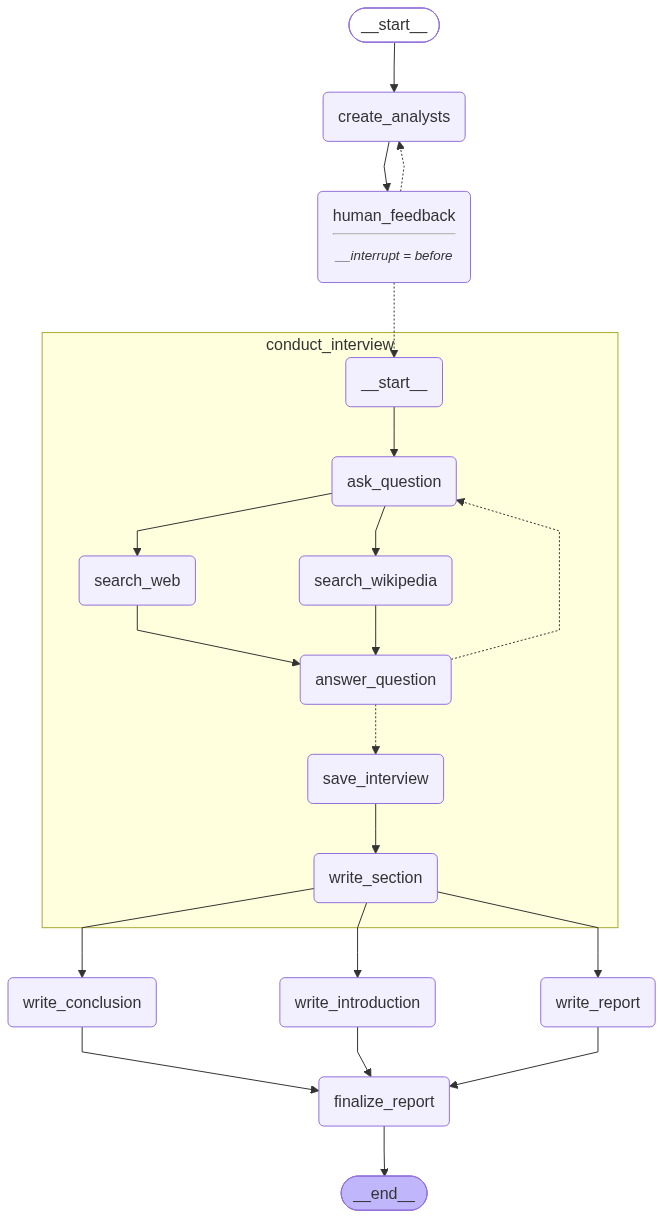

In [21]:
from langgraph.types import Send # updated in 1.0
def initiate_all_interviews(state: ResearchGraphState):
    """ This is the "map" step where we run each interview sub-graph using Send API """    

    # Check if human feedback
    human_analyst_feedback=state.get('human_analyst_feedback')
    if human_analyst_feedback:
        # Return to create_analysts
        return "create_analysts"

    # Otherwise kick off interviews in parallel via Send() API
    else:
        topic = state["topic"]
        return [Send("conduct_interview", {"analyst": analyst,
                                           "messages": [HumanMessage(
                                               content=f"So you said you were writing an article on {topic}?"
                                           )
                                                       ]}) for analyst in state["analysts"]]

report_writer_instructions = """You are a technical writer creating a report on this overall topic: 

{topic}
    
You have a team of analysts. Each analyst has done two things: 

1. They conducted an interview with an expert on a specific sub-topic.
2. They write up their finding into a memo.

Your task: 

1. You will be given a collection of memos from your analysts.
2. Think carefully about the insights from each memo.
3. Consolidate these into a crisp overall summary that ties together the central ideas from all of the memos. 
4. Summarize the central points in each memo into a cohesive single narrative.

To format your report:
 
1. Use markdown formatting. 
2. Include no pre-amble for the report.
3. Use no sub-heading. 
4. Start your report with a single title header: ## Insights
5. Do not mention any analyst names in your report.
6. Preserve any citations in the memos, which will be annotated in brackets, for example [1] or [2].
7. Create a final, consolidated list of sources and add to a Sources section with the `## Sources` header.
8. List your sources in order and do not repeat.

[1] Source 1
[2] Source 2

Here are the memos from your analysts to build your report from: 

{context}"""

def write_report(state: ResearchGraphState):
    # Full set of sections
    sections = state["sections"]
    topic = state["topic"]

    # Concat all sections together
    formatted_str_sections = "\n\n".join([f"{section}" for section in sections])
    
    # Summarize the sections into a final report
    system_message = report_writer_instructions.format(topic=topic, context=formatted_str_sections)    
    report = llm.invoke([SystemMessage(content=system_message)]+[HumanMessage(content=f"Write a report based upon these memos.")]) 
    return {"content": report.content}

intro_conclusion_instructions = """You are a technical writer finishing a report on {topic}

You will be given all of the sections of the report.

You job is to write a crisp and compelling introduction or conclusion section.

The user will instruct you whether to write the introduction or conclusion.

Include no pre-amble for either section.

Target around 100 words, crisply previewing (for introduction) or recapping (for conclusion) all of the sections of the report.

Use markdown formatting. 

For your introduction, create a compelling title and use the # header for the title.

For your introduction, use ## Introduction as the section header. 

For your conclusion, use ## Conclusion as the section header.

Here are the sections to reflect on for writing: {formatted_str_sections}"""

def write_introduction(state: ResearchGraphState):
    # Full set of sections
    sections = state["sections"]
    topic = state["topic"]

    # Concat all sections together
    formatted_str_sections = "\n\n".join([f"{section}" for section in sections])
    
    # Summarize the sections into a final report
    
    instructions = intro_conclusion_instructions.format(topic=topic, formatted_str_sections=formatted_str_sections)    
    intro = llm.invoke([instructions]+[HumanMessage(content=f"Write the report introduction")]) 
    return {"introduction": intro.content}

def write_conclusion(state: ResearchGraphState):
    # Full set of sections
    sections = state["sections"]
    topic = state["topic"]

    # Concat all sections together
    formatted_str_sections = "\n\n".join([f"{section}" for section in sections])
    
    # Summarize the sections into a final report
    
    instructions = intro_conclusion_instructions.format(topic=topic, formatted_str_sections=formatted_str_sections)    
    conclusion = llm.invoke([instructions]+[HumanMessage(content=f"Write the report conclusion")]) 
    return {"conclusion": conclusion.content}

def finalize_report(state: ResearchGraphState):
    """ The is the 'reduce' step: cleanly joins intro, body, and conclusion """
    content = extract_text(state.get("content", ""))
    intro = extract_text(state.get("introduction", ""))
    conclusion = extract_text(state.get("conclusion", ""))

    # Clean up duplicate headers
    if content.startswith("## Insights"):
        content = content[len("## Insights"):].lstrip()

    if "## Sources" in content:
        try:
            content, sources = content.split("\n## Sources\n", 1)
        except Exception:
            sources = None
    else:
        sources = None

    final_report = intro + "\n\n---\n\n" + content + "\n\n---\n\n" + conclusion
    if sources is not None:
        final_report += "\n\n## Sources\n" + sources
        
    return {"final_report": final_report}

# Add nodes and edges 
builder = StateGraph(ResearchGraphState)
builder.add_node("create_analysts", create_analysts)
builder.add_node("human_feedback", human_feedback)
builder.add_node("conduct_interview", interview_builder.compile())
builder.add_node("write_report",write_report)
builder.add_node("write_introduction",write_introduction)
builder.add_node("write_conclusion",write_conclusion)
builder.add_node("finalize_report",finalize_report)

# Logic
builder.add_edge(START, "create_analysts")
builder.add_edge("create_analysts", "human_feedback")
builder.add_conditional_edges("human_feedback", initiate_all_interviews, ["create_analysts", "conduct_interview"])
builder.add_edge("conduct_interview", "write_report")
builder.add_edge("conduct_interview", "write_introduction")
builder.add_edge("conduct_interview", "write_conclusion")
builder.add_edge(["write_conclusion", "write_report", "write_introduction"], "finalize_report")
builder.add_edge("finalize_report", END)

# Compile
memory = MemorySaver()
graph = builder.compile(interrupt_before=['human_feedback'], checkpointer=memory)
display(Image(graph.get_graph(xray=1).draw_mermaid_png()))

Let's ask an open-ended question about LangGraph.

In [22]:
# Inputs
max_analysts = 3 
topic = "The benefits of adopting LangGraph as an agent framework"
thread = {"configurable": {"thread_id": "1"}}

# Run the graph until the first interruption
for event in graph.stream({"topic":topic,
                           "max_analysts":max_analysts}, 
                          thread, 
                          stream_mode="values"):
    
    analysts = event.get('analysts', '')
    if analysts:
        for analyst in analysts:
            print(f"Name: {analyst.name}")
            print(f"Affiliation: {analyst.affiliation}")
            print(f"Role: {analyst.role}")
            print(f"Description: {analyst.description}")
            print("-" * 50)  

Name: Dr. Aris Thorne
Affiliation: Enterprise AI Architecture Group
Role: State Management and Robustness Expert
Description: Focuses on how LangGraph addresses the complexities of multi-agent state persistence, cyclic graphs, and fault tolerance in production environments, ensuring reliable long-running workflows.
--------------------------------------------------
Name: Elena Rostova
Affiliation: NextGen Autonomous Systems
Role: Multi-Agent Collaboration Strategist
Description: Examines the architectural benefits of LangGraph in orchestrating complex interactions, handoffs, and deterministic control flows between specialized AI agents compared to unstructured frameworks.
--------------------------------------------------
Name: Marcus Vance
Affiliation: Developer Experience Institute
Role: Developer Productivity and Observability Analyst
Description: Investigates how LangGraph improves debugging, testing, and tracing capabilities for developers building non-linear AI applications, lowe

In [23]:
# We now update the state as if we are the human_feedback node
graph.update_state(thread, {"human_analyst_feedback": 
                                "Add in the CEO of gen ai native startup"}, as_node="human_feedback")

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f1b058b-d731-692c-8002-b32d232c01c7'}}

In [24]:
# Check
for event in graph.stream(None, thread, stream_mode="values"):
    analysts = event.get('analysts', '')
    if analysts:
        for analyst in analysts:
            print(f"Name: {analyst.name}")
            print(f"Affiliation: {analyst.affiliation}")
            print(f"Role: {analyst.role}")
            print(f"Description: {analyst.description}")
            print("-" * 50)  

Name: Dr. Aris Thorne
Affiliation: Enterprise AI Architecture Group
Role: State Management and Robustness Expert
Description: Focuses on how LangGraph addresses the complexities of multi-agent state persistence, cyclic graphs, and fault tolerance in production environments, ensuring reliable long-running workflows.
--------------------------------------------------
Name: Elena Rostova
Affiliation: NextGen Autonomous Systems
Role: Multi-Agent Collaboration Strategist
Description: Examines the architectural benefits of LangGraph in orchestrating complex interactions, handoffs, and deterministic control flows between specialized AI agents compared to unstructured frameworks.
--------------------------------------------------
Name: Marcus Vance
Affiliation: Developer Experience Institute
Role: Developer Productivity and Observability Analyst
Description: Investigates how LangGraph improves debugging, testing, and tracing capabilities for developers building non-linear AI applications, lowe

In [25]:
# Confirm we are happy
graph.update_state(thread, {"human_analyst_feedback": 
                            None}, as_node="human_feedback")

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f1b058b-e8ba-615c-8004-dd8267f8e8de'}}

In [26]:
def extract_text(val):
    if isinstance(val, list):
        if val and isinstance(val[0], dict) and 'text' in val[0]:
            return val[0]['text']
        return "\n".join(str(v) for v in val)
    return str(val) if val is not None else ""

# Continue
for event in graph.stream(None, thread, stream_mode="updates"):
    print("--Node--")
    node_name = next(iter(event.keys()))
    print(node_name)

c:\Users\reich\Downloads\LangChain-Academy\2 - Introduction to LangGraph\.venv\Lib\site-packages\wikipedia\wikipedia.py:389: GuessedAtParserWarning: No parser was explicitly specified, so I'm using the best available HTML parser for this system ("html.parser"). This usually isn't a problem, but if you run this code on another system, or in a different virtual environment, it may use a different parser and behave differently.

The code that caused this warning is on line 389 of the file c:\Users\reich\Downloads\LangChain-Academy\2 - Introduction to LangGraph\.venv\Lib\site-packages\wikipedia\wikipedia.py. To get rid of this warning, pass the additional argument 'features="html.parser"' to the BeautifulSoup constructor.

  lis = BeautifulSoup(html).find_all('li')


--Node--
conduct_interview
--Node--
conduct_interview
--Node--
conduct_interview
--Node--
write_conclusion
--Node--
write_introduction
--Node--
write_report
--Node--
finalize_report


In [27]:
from IPython.display import Markdown
final_state = graph.get_state(thread)
report = final_state.values.get('final_report')
Markdown(report)

# Accelerating Time-to-Market and Scalability with LangGraph in Multi-Agent AI

## Introduction

As organizations increasingly deploy complex multi-agent systems, balancing development speed with system reliability remains a critical challenge. This report explores how adopting LangGraph transforms modern AI engineering by streamlining orchestration and accelerating time-to-market. We examine how the framework delivers robust architectural reliability through deterministic state management and fault-tolerant execution. Additionally, we analyze how LangGraph ensures enterprise-grade safety and transparency via native human-in-the-loop controls and fine-grained auditability. Ultimately, this report highlights how leveraging framework-driven architectures empowers engineering teams to transition fragile prototypes into scalable, production-ready applications.

---

The adoption of framework-driven architectures, specifically LangGraph, fundamentally transforms development velocity, architectural robustness, and safety in multi-agent artificial intelligence applications. Traditionally, building orchestrations for multi-agent workflows required burdensome, custom-built infrastructure that often delayed deployment, introduced points of failure, and struggled with unpredictable execution paths or state corruption [1]. As organizations face intense pressure to accelerate time-to-market while optimizing operational costs, transitioning to a graph-based execution layer offers a compelling solution to these engineering hurdles.

By leveraging LangGraph, engineering teams instantly secure a competitive edge through out-of-the-box durability, seamless scalability, and deterministic control loops that drastically reduce developer cognitive load. Moving away from unconstrained conversational loops and black-box agent autonomy, the framework treats agent interactions as structured, predictable state machines [1]. This architecture provides native support for state persistence, strict checkpointing, time-travel debugging, and deterministic state transitions natively within the workflow [1]. 

These capabilities allow developers to formally bound agent behavior, easily recover from mid-execution failures without losing computational progress, and ship sophisticated multi-agent products in a fraction of the usual time while driving down infrastructure overhead [1]. Furthermore, this stateful graph approach natively supports fine-grained checkpointing and structured human-in-the-loop (HITL) intervention points. Developers can pause execution at critical junctures, inspect intermediate states, approve or modify agent actions in real time, and replay or rollback execution paths when errors occur. Ultimately, LangGraph transforms autonomous agents from fragile, unpredictable entities into auditable, fault-tolerant, and collaborative production systems where human judgment remains reliably at the center of critical decision-making loops [1].


---

## Conclusion

Adopting LangGraph as an agent framework fundamentally transforms multi-agent AI development by solving critical production challenges. As explored in this report, LangGraph accelerates time-to-market and scalability while slashing infrastructure overhead through streamlined orchestration. Furthermore, its graph-based architecture delivers exceptional robustness via deterministic state management, time-travel debugging, and fault tolerance. Finally, the framework ensures rigorous safety and auditability by embedding native human-in-the-loop controls and structured state persistence. Ultimately, LangGraph bridges the gap between experimental autonomy and enterprise-grade reliability, empowering organizations to deploy sophisticated, scalable, and fully controllable multi-agent systems with confidence.

## Sources

[1] LangGraph Documentation and Architecture Guide
[2] Internal Expert Interview on LangGraph Agent Transparency and Human-in-the-Loop Control
[3] Internal Expert Interview on LangGraph Adoption and Multi-Agent Scalability (Internal Document Path: `/docs/interviews/langgraph-multi-agent-scalability.pdf`)